In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
# poznámka k trénování:
# jak zvolit trénovací a testovací množinu -> klíčové
# 1) zastoupení target class (vyrovnané vs nevyrovnané)
# 2) opakovaný výběr, cross-validace (typicky 10) - bez opakování, bootstraping - s opakování

# rozdělení na testovací a trénovací je typicky kvůli evaluaci, 
# výsledný model může být trénován na celých datech -> pozor, může dojít ke změně výsledků klasifikace!!!

In [2]:
# jednoducha implementace k-nearest neighbours (KNN)
class KNN:
    def __init__(self, k=3):
        self.k = k
        self.X_train = None
        self.y_train = None
            
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y 
    
    def predict(self, X):
        predictions = []
        for p in X:
            # vse provadime vektorove (zrychleni)
            # vypocet vzdalenosti
            euclidean_distances = [self._euclidean_distance(p, q) for q in self.X_train]
            
            # seradime dle vzdalenosti a vybereme k nejlepsich
            sorted_k = np.argsort(euclidean_distances)[:self.k]
            
            # zjistime predikce nejblizsich sousedu
            k_nearest = [self.y_train[y] for y in sorted_k]
            
            # vybereme nejcastejsi predikci 
            predictions.append(stats.mode(k_nearest)[0][0])
            
        return np.array(predictions)
    
    def _euclidean_distance(self, p, q):
        return np.sqrt(np.sum((p - q) ** 2))

In [3]:
# https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+(diagnostic)
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
X = data.data
y = data.target 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [4]:
model = KNN(3)
model.fit(X_train, y_train)
y_predicted = model.predict(X_test)

<AxesSubplot:>

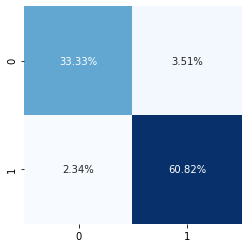

In [5]:
from sklearn.metrics import classification_report, confusion_matrix
cf_matrix = confusion_matrix(y_test, y_predicted)

sns.heatmap(cf_matrix/np.sum(cf_matrix), square=True, annot=True, fmt='.2%', cmap='Blues', cbar=False)

In [6]:
print(classification_report(y_test, y_predicted, labels=[0, 1]))

              precision    recall  f1-score   support

           0       0.93      0.90      0.92        63
           1       0.95      0.96      0.95       108

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171



In [7]:
# dobrovolné úkoly 
# implementujte další vzdálenosti, jaký je jejich vliv na predikci ve výše uvedených datech?
# jaký je vliv počtu sousedů?

In [ ]:
# proč vlastní implementace?
# např. approximate nearest neighbors (ANN)